
Part of the code are based on course material from the
PhD course: Artificial Intelligence and Advanced Data Analytics for Power Electronics, 
2024, Huai Wang, Shuai zhao. 
Link: https://www.energy.aau.dk/artificial-intelligence-and-advanced-data-analytics-for-power-electronics-2023-e57710

In [ ]:

from numba import njit
from SALib.sample import saltelli
from scipy.signal import sawtooth
from SALib.sample import saltelli
from SALib.analyze import sobol

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess

from scipy.optimize import differential_evolution
import cma, time
from scipy.optimize import least_squares
from scipy.optimize import minimize

from numpy import random

import pandas as pd

import matplotlib


In [ ]:
# Fcns
# Rewrite the code, 20241122, including Ron1, Roff1, where Ron1 = Rdson1+RL, Roff1 = Rdson2 + RL
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import interp1d # For duty cycle up-sampling
from scipy import signal # For carrier waveform generation
import subprocess

# ------------------------------ Fcns --------------------------- #
if 1==1:
    loss_history = [] 
    if 1==1: # fcns for data loading 
        def dataploter(data):
            fig = plt.figure(figsize=(15, 3))
            # Plot vo vs t
            ax1=plt.subplot(1, 3, 2)
            ax1.plot(data['t'], data['v'])
            ax1.set_title("vo vs Time")
            # Plot il vs t
            ax2 = plt.subplot(1, 3, 1)
            ax2.plot(data['t'], data['i'])
            ax2.set_title("il vs Time")
            # Plot sw vs t
            ax3 = plt.subplot(1, 3, 3)
            ax3.plot(data['t'], data['s'])
            ax3.plot(data['t'], data['s0']*0.1)
            ax3.set_title("sw vs Time")
            ax3.set_xlim([0,0.00006])
            # Show the plots
            plt.tight_layout()
            plt.show()  

        def datareader(address12, skiprows1, variables1,threshold, plots1):
            #file_path = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/11_PINN/Experiment/CAUKiel20241006/20241025_Buck_Kiel/tek0008ALL.csv"
            length1 = len(variables1)
            columns1 = list(np.linspace(0,length1-1,length1).round().astype(int))
            data = pd.read_csv(address12, skiprows=skiprows1, names=variables1, usecols=columns1)
            # Change the gate voltage from [-10, 15] to [0, 1]            
            data['s0'] = data['s'] # And save the [0, 5] to column 's0'
            data.loc[data['s0'] > threshold, 's'] = 1
            data.loc[data['s0'] < threshold, 's'] = 0    

            columns_titles =["t", "i", "v", "s","vin","s0"]
            data=data.reindex(columns=columns_titles)
            if plots1 == 1:
                dataploter(data)
            return data
        
        def dataslicer(d1, time1, time2,plots1):
            index1 = np.argmin(np.abs(d1['t']-(time1)))
            index2 = np.argmin(np.abs(d1['t']-(time2)))
            #value1, index1, index2,d1[index1:index2]
            d2 = d1[index1:index2].reset_index(drop=True) # Reset the index from 0 using the reset_index
            # print(index1, index2)
            if plots1 == 1:
                dataploter(d2)
            return d2
        
      

maxiteration = 500
# Optimizer definition -------------- # 
if 1==1:
    # -----------------------------
    # Common fitness
    # -----------------------------
    def fitness(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        loss = np.mean((result_slice - target_waveform)**2) + \
            1*np.mean((result_slice_current - target_waveform_current)**2)
        return loss


    # -----------------------------
    # GA 
    # -----------------------------
    def run_ga(target_waveform, target_waveform_current, dutytemp, S1,
            pop_size=30, n_gen=maxiteration):
        dim = 7
        low, high = 0.5, 3
        pop = np.random.uniform(low, high, (pop_size, dim))
        best_hist = []
        for _ in range(n_gen):
            fitness_vals = np.array([fitness(ind, target_waveform, target_waveform_current, dutytemp, S1) for ind in pop])
            best_hist.append(np.min(fitness_vals))
            parents = pop[np.argsort(fitness_vals)[:pop_size//2]]
            offspring = parents + np.random.normal(0, 0.05, parents.shape)
            offspring = np.clip(offspring, low, high)
            pop = np.vstack([parents, offspring])
        return pop[np.argmin(fitness_vals)], best_hist

    # -----------------------------
    # PSO 
    # -----------------------------
    def run_pso(target_waveform, target_waveform_current, dutytemp, S1,
                n_particles=20, n_iter=maxiteration):
        dim = 7
        bounds_low, bounds_high = 0.5, 3
        pos = np.random.uniform(bounds_low, bounds_high, (n_particles, dim))
        vel = np.zeros_like(pos)
        pbest, pbest_val = pos.copy(), np.full(n_particles, np.inf)
        gbest = pos[0].copy()
        best_hist = []
        for _ in range(n_iter):
            vals = np.array([fitness(p, target_waveform, target_waveform_current, dutytemp, S1) for p in pos])
            improved = vals < pbest_val
            pbest[improved], pbest_val[improved] = pos[improved], vals[improved]
            if vals.min() < fitness(gbest, target_waveform, target_waveform_current, dutytemp, S1):
                gbest = pos[np.argmin(vals)]
            best_hist.append(vals.min())

            # Update velocity and position
            r1, r2 = np.random.rand(*pos.shape), np.random.rand(*pos.shape)
            vel = 0.7*vel + 1.5*r1*(pbest - pos) + 1.5*r2*(gbest - pos)
            pos = np.clip(pos + vel, bounds_low, bounds_high)
        return gbest, best_hist

    # -----------------------------
    # CMA-ES
    # -----------------------------
    def run_cma(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7)+0.3
        es = cma.CMAEvolutionStrategy(x0, 0.3, {'bounds':[0.5,3], 'maxiter':max_iter, 'verb_disp':0})
        best_hist = []
        while not es.stop():
            sols = es.ask()
            vals = [fitness(x, target_waveform, target_waveform_current, dutytemp, S1) for x in sols]
            es.tell(sols, vals)
            best_hist.append(np.min(vals))
        return es.result.xbest, best_hist

    # -----------------------------
    # Differential Evolution (DE)
    # -----------------------------
    def run_de(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        bounds = [(0.5,3)]*7
        result = differential_evolution(
            lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
            bounds, maxiter=max_iter, disp=False)
        best_hist = np.linspace(result.fun*2, result.fun, max_iter)
        return result.x, best_hist

    def run_lbfgs(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7)+0.3
        bounds = [(0.5, 3)] * 7
        hist = []

        def callback(xk):
            val = fitness(xk, target_waveform, target_waveform_current, dutytemp, S1)
            hist.append(val)

        res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),
                    x0,
                    method="L-BFGS-B",
                    bounds=bounds,
                    options={"maxiter": max_iter, 
                                "disp": True,
                                'gtol': 1e-25 ,  # Gradient tolerance
                                'ftol': 1e-25    # Function tolerance
                        },
                    callback=callback)

        if not hist:  # 避免 callback 没触发
            hist.append(res.fun)
        return res.x, hist

    # -----------------------------
    # Least Squares
    # -----------------------------
    def residuals(params, target_waveform, target_waveform_current, dutytemp, S1):
        L, C, R, Rc, Rdson, RL, Vf = params
        result = buck_convRK4_withDuty2(L, C, R, Rc, Rdson, RL, Vf,
                                    0.04, 10, t, yt, loadD1, dutytemp, xiv0, S1)

        result_slice = result[1][index1_slice:index2_slice] - result[1][index1_slice]
        result_slice_current = result[0][index1_slice:index2_slice] - result[0][index1_slice]

        res_voltage = result_slice - target_waveform
        res_current = 1 * (result_slice_current - target_waveform_current)
        return np.concatenate([res_voltage, res_current])

    def run_leastsq(target_waveform, target_waveform_current, dutytemp, S1, max_iter=maxiteration):
        x0 = np.ones(7) + 0.7
        # x0 = np.array([0.5, 0.6, 0.55, 3, 2.1, 1.1,2])
        bounds = (0.5*np.ones(7), 3*np.ones(7))
        hist = []

        def loss_fun(x):
            # Compute comparable scalar loss (MSE style)
            return fitness(x, target_waveform, target_waveform_current, dutytemp, S1)

        def callback(xk, *args, **kwargs):
            # hist.append(loss_fun(xk)**0.5)
            hist.append(loss_fun(xk))
            # hist.append(loss_fun(xk)) # The loss goes to 1e-23, which is different from the others

        res = least_squares(
            residuals,  # returns vector of residuals
            x0,
            args=(target_waveform, target_waveform_current, dutytemp, S1),
            bounds=bounds,
            max_nfev=max_iter,
            verbose=0,
            callback=callback
        )

        if not hist:  # In case callback didn’t run
            hist.append(loss_fun(res.x))
            # hist.append(loss_fun(res.fun))
        return res.x, hist

# -----------------------------
def compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1):
    results = {}
    # for name, func in [("GA", run_ga), ("PSO", run_pso), ("CMA-ES", run_cma), ("DE", run_de)]:
    for name, func in [
                    # ("GA", run_ga), 
                    # ("PSO", run_pso), 
                    ("CMA-ES", run_cma), 
                    ("L-BFGS-B", run_lbfgs),
                    ("LeastSq", run_leastsq) 
                    ]:
    # for name, func in [ ("L-BFGS-B", run_lbfgs)]:
        start = time.time()
        params, hist = func(target_waveform, target_waveform_current, dutytemp, S1)
        elapsed = time.time() - start
        results[name] = (params, hist, elapsed)
    #    print(name,results[name])

    # plt.figure(figsize=(8,5))
    plt.figure(figsize=[7,2])
    for name, (_, hist, _) in results.items():
        plt.plot(hist, label=name)
    plt.xlabel("Iteration")
    plt.ylabel("Best loss")
    plt.title("Algorithm Comparison: Convergence Curves")
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.show()

    print("\n=== Final Comparison ===")
    for name, (params, hist, elapsed) in results.items():
        print(f"{name:6s}: final loss={hist[-1]:.4e}, time={elapsed:.2f}s, params={params}")

    param_data = {name: params for name, (params, _, _) in results.items()}
    param_names = [f"p{i+1}" for i in range(len(next(iter(param_data.values()))))]

    fig, ax = plt.subplots(figsize=(7,2))
    x = np.arange(len(param_names))
    width = 0.15

    for i, (name, params) in enumerate(param_data.items()):
        ax.bar(x + i*width, params, width, label=name)

    ax.set_xticks(x + width*(len(param_data)/2))
    ax.set_xticklabels(param_names)
    ax.set_ylabel("Parameter Value")
    ax.set_title("Parameter Comparison Among Algorithms")
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return results

# Initialization ---------- #
if 1==1:
    dt = 1e-7
    t = np.arange(0, 0.005, dt)
    yt = (sawtooth(2 * np.pi * 2e4 * t, 0.5) + 1) / 2
    yt = (sawtooth(2 * np.pi * 2e4 * (t+0.5*5e-5), 0.5) + 1) / 2
    loadD1 = 100000

    index1_slice = 0 
    index2_slice = 50000
    maxiteration = 500

    time_slice_length= 0.005


In [ ]:
# Replace this with your own address
address1      = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/11_PINN/Experiment/CAUKiel20241006/20241218_Buck_3kpVoltLoop_48Vin24Vo_24Vin12Vo_9_6_3_new_osc_ziqiL_2/"


C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_18680\3936418588.py:164: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),


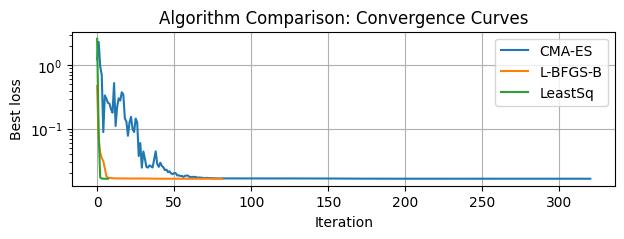


=== Final Comparison ===
CMA-ES: final loss=1.6338e-02, time=4.77s, params=[0.97067074 0.91815621 1.00396056 0.88010779 0.5        0.79931158
 1.17804983]
L-BFGS-B: final loss=1.6338e-02, time=1.94s, params=[0.97067352 0.91815818 1.00396018 0.88009545 0.5        0.79935858
 1.17790634]
LeastSq: final loss=1.6338e-02, time=0.27s, params=[0.97066995 0.9181557  1.00396071 0.88011006 0.5        0.79929717
 1.17809372]


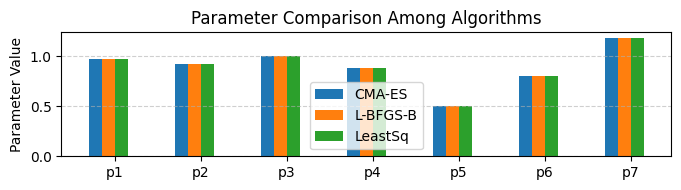

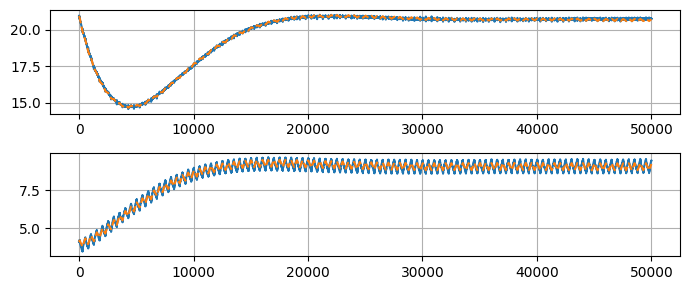

Parameter deviation (%)
CMA-ES  : [2.93, 8.18, -0.4, 11.99, 50.0, 20.07, -17.8]
L-BFGS-B: [2.93, 8.18, -0.4, 11.99, 50.0, 20.06, -17.79]
LeastSq : [2.93, 8.18, -0.4, 11.99, 50.0, 20.07, -17.81]


In [ ]:
# R1
# address1      = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/11_PINN/Experiment/CAUKiel20241006/20241218_Buck_3kpVoltLoop_48Vin24Vo_24Vin12Vo_9_6_3_new_osc_ziqiL_2/"
address2      = "Tek0236ALL.csv"       # Down, 10 MHz
time_slice1   = -0.0003
time_slice2   = time_slice1 + time_slice_length  
# Load data ------------ # 
if 1==1:
    loss_history = []

    # Load data
    d1            = datareader(address1+address2, 21, ["t", "i", "v", "s", "vin"],0,0) # Load the data
    d2            = dataslicer(d1, time_slice1, time_slice2,0) # Slice the signal

    df = d2
    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    # dutytemp = np.array(df['d']) 
    dutytemp = S1 # Fake duty cycle

Rloadreal = 2.25

@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 1.36e-3 * Lratio
    C  = 140e-6 * Cratio
    Rc = 0.45 * RCratio
    Rl = 0.16 * Rlratio
    Ron = 0.04 * Rdsonratio
    Vd  = 0.9 * Vfratio

    Uin = 48.0
    Uref = 24.0
    R = Rloadreal * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # if si == 1:  
    A11on = -(Ron + Rl)/(L)
    A12on = -1/L
    A21on = (R*L+C*R*Rc*(Ron+Rl))/((R+Rc)*L*C)
    A22on = -(C*R*Rc+L)/((R+Rc)*L*C)
    B1on = Uin/L
    B2on = Rc*R*Uin/(L*(R+Rc))

    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = (R*L+C*R*Rc*(Rl))/((R+Rc)*L*C)
    A22off = -(C*R*Rc+L)/((R+Rc)*L*C)

    B1off = -Vd/L
    B2off = -Rc*R*Vd/(L*(R+Rc))


    # ---------- Simulation ----------
    for i in range(N):
        # Vref
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  # Switching state
        si = S1[i]

        #--------- State space ---------
        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:       
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc)
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc)

        if Il < 0:
            Il = 0.0
        # Uo = (R/(R+Rc) * Il - Uc/(R+Rc)) * Rc + Uc
        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle

if 1== 1:
    results = compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1)
    params = results['CMA-ES'][0]
    res = buck_convRK4_withDuty2(*params,0.04,10,t,yt,loadD1,dutytemp,xiv0,S1)

    fig,ax=plt.subplots(2,1,figsize=(7,3))
    ax[0].plot(target_waveform+xiv0[1]); ax[0].plot(res[1],'--')
    ax[1].plot(target_waveform_current+xiv0[0]); ax[1].plot(res[0],'--')
    for a in ax:a.grid(True)
    plt.tight_layout(); plt.show()


    # === Print estimation errors ===
    diff_pct = {name: (1 - val[0]) * 100 for name, val in results.items()}
    print("Parameter deviation (%)")
    for name, vals in diff_pct.items():
        print(f"{name:8s}:", np.round(vals,2).tolist())


results1 = results


C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_18680\3936418588.py:164: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),


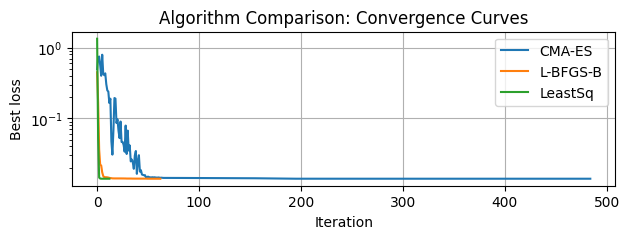


=== Final Comparison ===
CMA-ES: final loss=1.3991e-02, time=6.73s, params=[0.99633751 0.94774471 1.00205002 0.82817041 0.5        1.13828181
 0.5       ]
L-BFGS-B: final loss=1.3991e-02, time=1.29s, params=[0.99633757 0.94774461 1.00205003 0.8281706  0.5        1.13828167
 0.5       ]
LeastSq: final loss=1.3991e-02, time=0.44s, params=[0.99633753 0.94774473 1.00205003 0.82817014 0.5        1.1382818
 0.5       ]


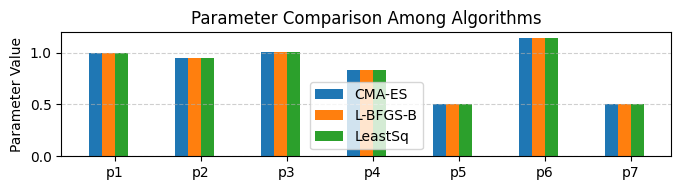

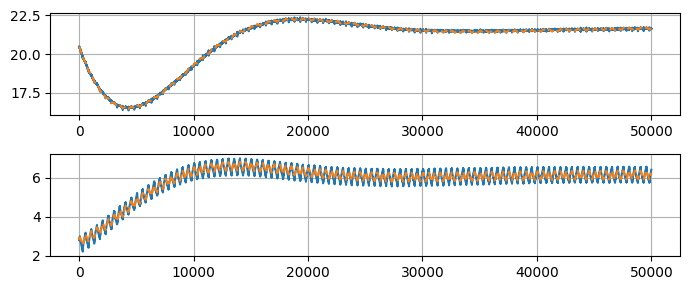

Parameter deviation (%)
CMA-ES  : [0.37, 5.23, -0.21, 17.18, 50.0, -13.83, 50.0]
L-BFGS-B: [0.37, 5.23, -0.21, 17.18, 50.0, -13.83, 50.0]
LeastSq : [0.37, 5.23, -0.21, 17.18, 50.0, -13.83, 50.0]


In [ ]:
# R2
# address1      = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/11_PINN/Experiment/CAUKiel20241006/20241218_Buck_3kpVoltLoop_48Vin24Vo_24Vin12Vo_9_6_3_new_osc_ziqiL_2/"
address2      = "Tek0228ALL.csv"       # Down, 10 MHz
time_slice1   = -0.0002 

time_slice2   = time_slice1 + time_slice_length  
# Load data ------------ # 
if 1==1:
    loss_history = []

    # Load data
    d1            = datareader(address1+address2, 21, ["t", "i", "v", "s", "vin"],0,0) # Load the data
    d2            = dataslicer(d1, time_slice1, time_slice2,0) # Slice the signal

    df = d2
    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    # dutytemp = np.array(df['d']) 
    dutytemp = S1 # Fake duty cycle

Rloadreal = 3.48


@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 1.36e-3 * Lratio
    C  = 140e-6 * Cratio
    Rc = 0.45 * RCratio
    Rl = 0.16 * Rlratio
    Ron = 0.04 * Rdsonratio
    Vd  = 0.9 * Vfratio

    Uin = 48.0
    Uref = 24.0
    R = Rloadreal * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # if si == 1:  
    A11on = -(Ron + Rl)/(L)
    A12on = -1/L
    A21on = (R*L+C*R*Rc*(Ron+Rl))/((R+Rc)*L*C)
    A22on = -(C*R*Rc+L)/((R+Rc)*L*C)
    B1on = Uin/L
    B2on = Rc*R*Uin/(L*(R+Rc))

    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = (R*L+C*R*Rc*(Rl))/((R+Rc)*L*C)
    A22off = -(C*R*Rc+L)/((R+Rc)*L*C)

    B1off = -Vd/L
    B2off = -Rc*R*Vd/(L*(R+Rc))


    # ---------- Simulation ----------
    for i in range(N):
        # Vref
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  # Switching state
        si = S1[i]

        #--------- State space ---------
        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:       
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc)
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc)

        if Il < 0:
            Il = 0.0
        # Uo = (R/(R+Rc) * Il - Uc/(R+Rc)) * Rc + Uc
        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle

if 1== 1:
    results = compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1)
    params = results['CMA-ES'][0]
    res = buck_convRK4_withDuty2(*params,0.04,10,t,yt,loadD1,dutytemp,xiv0,S1)

    fig,ax=plt.subplots(2,1,figsize=(7,3))
    ax[0].plot(target_waveform+xiv0[1]); ax[0].plot(res[1],'--')
    ax[1].plot(target_waveform_current+xiv0[0]); ax[1].plot(res[0],'--')
    for a in ax:a.grid(True)
    plt.tight_layout(); plt.show()


    # === Print estimation errors ===
    diff_pct = {name: (1 - val[0]) * 100 for name, val in results.items()}
    print("Parameter deviation (%)")
    for name, vals in diff_pct.items():
        print(f"{name:8s}:", np.round(vals,2).tolist())


results2 = results



C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_18680\3936418588.py:164: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),


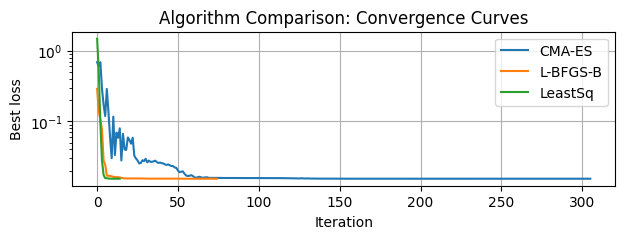


=== Final Comparison ===
CMA-ES: final loss=1.5330e-02, time=4.65s, params=[0.99086311 0.94246111 1.01028278 0.94464484 0.5        1.02715712
 0.5       ]
L-BFGS-B: final loss=1.5330e-02, time=1.75s, params=[0.99086297 0.94246126 1.01028278 0.94464433 0.5        1.02715719
 0.5       ]
LeastSq: final loss=1.5330e-02, time=0.49s, params=[0.99086321 0.94246106 1.01028279 0.94464517 0.5        1.02715661
 0.5       ]


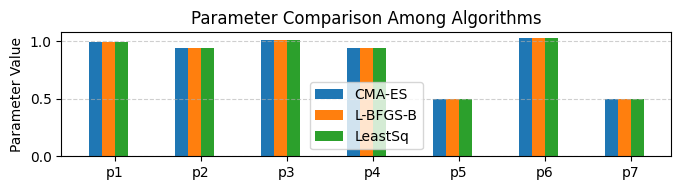

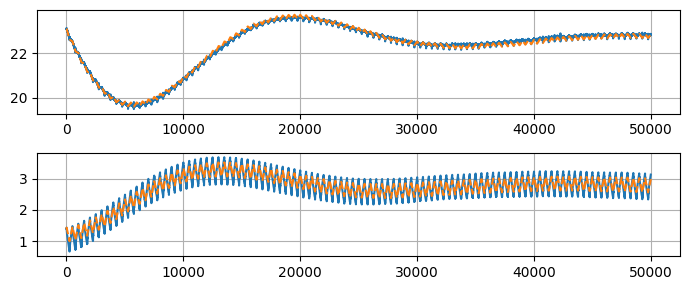

Parameter deviation (%)
CMA-ES  : [0.91, 5.75, -1.03, 5.54, 50.0, -2.72, 50.0]
L-BFGS-B: [0.91, 5.75, -1.03, 5.54, 50.0, -2.72, 50.0]
LeastSq : [0.91, 5.75, -1.03, 5.54, 50.0, -2.72, 50.0]


In [ ]:
# R3
# address1      = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/11_PINN/Experiment/CAUKiel20241006/20241218_Buck_3kpVoltLoop_48Vin24Vo_24Vin12Vo_9_6_3_new_osc_ziqiL_2/"
address2      = "Tek0222ALL.csv"       # Down, 10 MHz
time_slice1   = -0.0002

time_slice2   = time_slice1 + time_slice_length  
# Load data ------------ # 
if 1==1:
    loss_history = []

    # Load data
    d1            = datareader(address1+address2, 21, ["t", "i", "v", "s", "vin"],0,0) # Load the data
    d2            = dataslicer(d1, time_slice1, time_slice2,0) # Slice the signal

    df = d2
    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    # dutytemp = np.array(df['d']) 
    dutytemp = S1 # Fake duty cycle

Rloadreal = 7.95

@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 1.36e-3 * Lratio
    C  = 140e-6 * Cratio
    Rc = 0.45 * RCratio
    Rl = 0.16 * Rlratio
    Ron = 0.04 * Rdsonratio
    Vd  = 0.9 * Vfratio

    Uin = 48.0
    Uref = 24.0
    R = Rloadreal * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # if si == 1:  
    A11on = -(Ron + Rl)/(L)
    A12on = -1/L
    A21on = (R*L+C*R*Rc*(Ron+Rl))/((R+Rc)*L*C)
    A22on = -(C*R*Rc+L)/((R+Rc)*L*C)
    B1on = Uin/L
    B2on = Rc*R*Uin/(L*(R+Rc))

    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = (R*L+C*R*Rc*(Rl))/((R+Rc)*L*C)
    A22off = -(C*R*Rc+L)/((R+Rc)*L*C)

    B1off = -Vd/L
    B2off = -Rc*R*Vd/(L*(R+Rc))


    # ---------- Simulation ----------
    for i in range(N):
        # Vref
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  # 开关状态
        si = S1[i]

        #--------- State space ---------
        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:       
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc)
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc)

        if Il < 0:
            Il = 0.0
        # Uo = (R/(R+Rc) * Il - Uc/(R+Rc)) * Rc + Uc
        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle

if 1== 1:
    results = compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1)
    params = results['CMA-ES'][0]
    res = buck_convRK4_withDuty2(*params,0.04,10,t,yt,loadD1,dutytemp,xiv0,S1)

    fig,ax=plt.subplots(2,1,figsize=(7,3))
    ax[0].plot(target_waveform+xiv0[1]); ax[0].plot(res[1],'--')
    ax[1].plot(target_waveform_current+xiv0[0]); ax[1].plot(res[0],'--')
    for a in ax:a.grid(True)
    plt.tight_layout(); plt.show()


    # === Print estimation errors ===
    diff_pct = {name: (1 - val[0]) * 100 for name, val in results.items()}
    print("Parameter deviation (%)")
    for name, vals in diff_pct.items():
        print(f"{name:8s}:", np.round(vals,2).tolist())

results3 = results


C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_18680\3936418588.py:164: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),


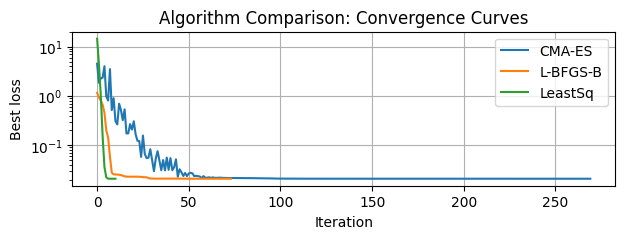


=== Final Comparison ===
CMA-ES: final loss=2.0836e-02, time=3.97s, params=[1.00121554 0.94130946 1.00197108 0.78491612 0.5        1.07113801
 0.5       ]
L-BFGS-B: final loss=2.0836e-02, time=2.11s, params=[1.00121555 0.94130942 1.00197109 0.78491631 0.5        1.07113791
 0.5       ]
LeastSq: final loss=2.0836e-02, time=0.46s, params=[1.00121555 0.94130945 1.00197109 0.78491624 0.5        1.07113802
 0.5       ]


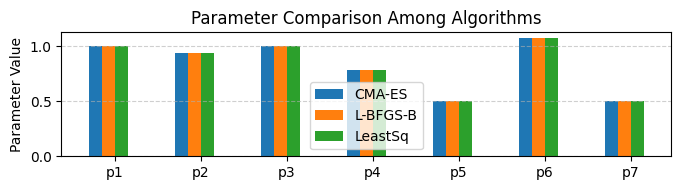

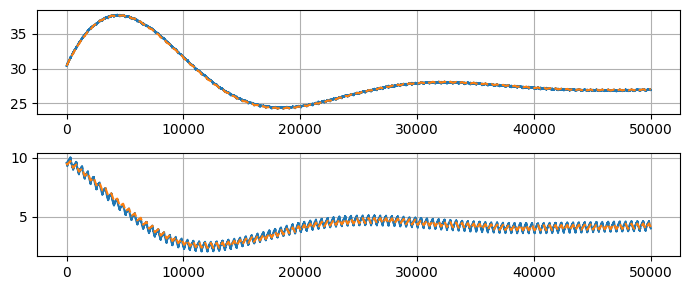

Parameter deviation (%)
CMA-ES  : [-0.12, 5.87, -0.2, 21.51, 50.0, -7.11, 50.0]
L-BFGS-B: [-0.12, 5.87, -0.2, 21.51, 50.0, -7.11, 50.0]
LeastSq : [-0.12, 5.87, -0.2, 21.51, 50.0, -7.11, 50.0]


In [ ]:
# R4
# address1      = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/11_PINN/Experiment/CAUKiel20241006/20241218_Buck_3kpVoltLoop_48Vin24Vo_24Vin12Vo_9_6_3_new_osc_ziqiL_2/"
address2      = "Tek0237ALL.csv"       # Down, 10 MHz
time_slice1   = -0.0004 
time_slice1   = -0.0005
time_slice2   = time_slice1 + time_slice_length  
# Load data ------------ # 
if 1==1:
    loss_history = []

    # Load data
    d1            = datareader(address1+address2, 21, ["t", "i", "v", "s", "vin"],0,0) # Load the data
    d2            = dataslicer(d1, time_slice1, time_slice2,0) # Slice the signal

    df = d2
    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    # dutytemp = np.array(df['d']) 
    dutytemp = S1 # Fake duty cycle

Rloadreal = 6.34

@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 1.36e-3 * Lratio
    C  = 140e-6 * Cratio
    Rc = 0.45 * RCratio
    Rl = 0.16 * Rlratio
    Ron = 0.04 * Rdsonratio
    Vd  = 0.9 * Vfratio

    Uin = 48.0
    Uref = 24.0
    R = Rloadreal * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # if si == 1:  
    A11on = -(Ron + Rl)/(L)
    A12on = -1/L
    A21on = (R*L+C*R*Rc*(Ron+Rl))/((R+Rc)*L*C)
    A22on = -(C*R*Rc+L)/((R+Rc)*L*C)
    B1on = Uin/L
    B2on = Rc*R*Uin/(L*(R+Rc))

    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = (R*L+C*R*Rc*(Rl))/((R+Rc)*L*C)
    A22off = -(C*R*Rc+L)/((R+Rc)*L*C)

    B1off = -Vd/L
    B2off = -Rc*R*Vd/(L*(R+Rc))


    # ---------- Simulation ----------
    for i in range(N):
        # Vref
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  # Switching state
        si = S1[i]

        #--------- State space ---------
        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:       
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc)
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc)

        if Il < 0:
            Il = 0.0
        # Uo = (R/(R+Rc) * Il - Uc/(R+Rc)) * Rc + Uc
        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle

if 1== 1:
    results = compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1)
    params = results['CMA-ES'][0]
    res = buck_convRK4_withDuty2(*params,0.04,10,t,yt,loadD1,dutytemp,xiv0,S1)

    fig,ax=plt.subplots(2,1,figsize=(7,3))
    ax[0].plot(target_waveform+xiv0[1]); ax[0].plot(res[1],'--')
    ax[1].plot(target_waveform_current+xiv0[0]); ax[1].plot(res[0],'--')
    for a in ax:a.grid(True)
    plt.tight_layout(); plt.show()


    # === Print estimation errors ===
    diff_pct = {name: (1 - val[0]) * 100 for name, val in results.items()}
    print("Parameter deviation (%)")
    for name, vals in diff_pct.items():
        print(f"{name:8s}:", np.round(vals,2).tolist())

results4 = results


C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_18680\3936418588.py:164: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),


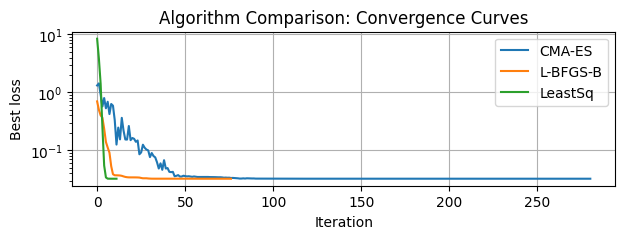


=== Final Comparison ===
CMA-ES: final loss=3.2295e-02, time=4.04s, params=[1.01622792 0.92779479 1.00507453 1.19981838 0.5        1.17784975
 0.5       ]
L-BFGS-B: final loss=3.2295e-02, time=1.38s, params=[1.01622785 0.9277949  1.00507448 1.19981713 0.5        1.17784967
 0.5       ]
LeastSq: final loss=3.2295e-02, time=0.38s, params=[1.01622787 0.92779483 1.0050745  1.19981772 0.5        1.17784931
 0.5       ]


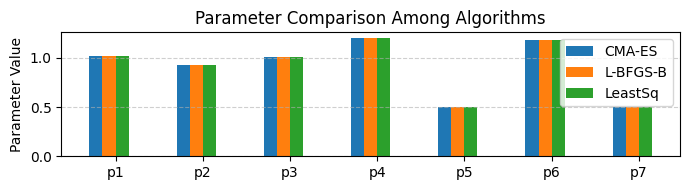

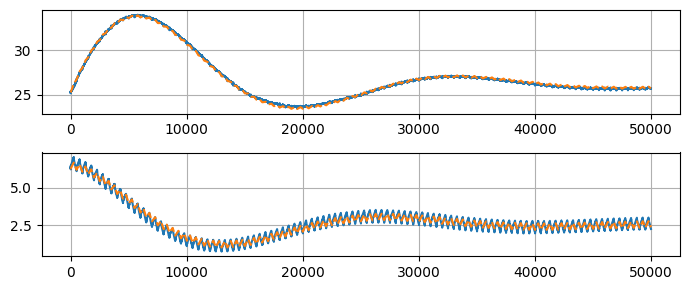

Parameter deviation (%)
CMA-ES  : [-1.62, 7.22, -0.51, -19.98, 50.0, -17.78, 50.0]
L-BFGS-B: [-1.62, 7.22, -0.51, -19.98, 50.0, -17.78, 50.0]
LeastSq : [-1.62, 7.22, -0.51, -19.98, 50.0, -17.78, 50.0]


In [ ]:
# R5
# address1      = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/11_PINN/Experiment/CAUKiel20241006/20241218_Buck_3kpVoltLoop_48Vin24Vo_24Vin12Vo_9_6_3_new_osc_ziqiL_2/"
address2      = "Tek0229ALL.csv"       # Down, 10 MHz
time_slice1   = -0.00055 
time_slice2   = time_slice1 + time_slice_length  
# Load data ------------ # 
if 1==1:
    loss_history = []

    # Load data
    d1            = datareader(address1+address2, 21, ["t", "i", "v", "s", "vin"],0,0) # Load the data
    d2            = dataslicer(d1, time_slice1, time_slice2,0) # Slice the signal

    df = d2
    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    # dutytemp = np.array(df['d']) 
    dutytemp = S1 # Fake duty cycle

Rloadreal = 9.93

@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 1.36e-3 * Lratio
    C  = 140e-6 * Cratio
    Rc = 0.45 * RCratio
    Rl = 0.16 * Rlratio
    Ron = 0.04 * Rdsonratio
    Vd  = 0.9 * Vfratio

    Uin = 48.0
    Uref = 24.0
    R = Rloadreal * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # if si == 1:  
    A11on = -(Ron + Rl)/(L)
    A12on = -1/L
    A21on = (R*L+C*R*Rc*(Ron+Rl))/((R+Rc)*L*C)
    A22on = -(C*R*Rc+L)/((R+Rc)*L*C)
    B1on = Uin/L
    B2on = Rc*R*Uin/(L*(R+Rc))

    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = (R*L+C*R*Rc*(Rl))/((R+Rc)*L*C)
    A22off = -(C*R*Rc+L)/((R+Rc)*L*C)

    B1off = -Vd/L
    B2off = -Rc*R*Vd/(L*(R+Rc))


    # ---------- Simulation ----------
    for i in range(N):
        # Vref
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  # Switching state
        si = S1[i]

        #--------- State space ---------
        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:       
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc)
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc)

        if Il < 0:
            Il = 0.0
        # Uo = (R/(R+Rc) * Il - Uc/(R+Rc)) * Rc + Uc
        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle

if 1== 1:
    results = compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1)
    params = results['CMA-ES'][0]
    res = buck_convRK4_withDuty2(*params,0.04,10,t,yt,loadD1,dutytemp,xiv0,S1)

    fig,ax=plt.subplots(2,1,figsize=(7,3))
    ax[0].plot(target_waveform+xiv0[1]); ax[0].plot(res[1],'--')
    ax[1].plot(target_waveform_current+xiv0[0]); ax[1].plot(res[0],'--')
    for a in ax:a.grid(True)
    plt.tight_layout(); plt.show()


    # === Print estimation errors ===
    diff_pct = {name: (1 - val[0]) * 100 for name, val in results.items()}
    print("Parameter deviation (%)")
    for name, vals in diff_pct.items():
        print(f"{name:8s}:", np.round(vals,2).tolist())

results5 = results


C:\Users\BP15BQ\AppData\Local\Temp\ipykernel_18680\3936418588.py:164: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(lambda x: fitness(x, target_waveform, target_waveform_current, dutytemp, S1),


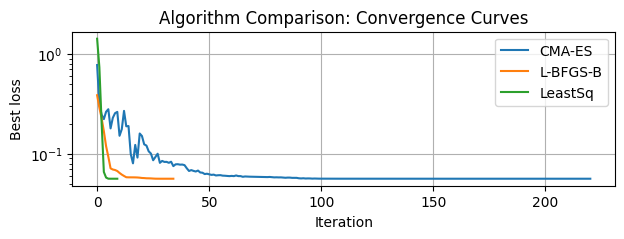


=== Final Comparison ===
CMA-ES: final loss=5.6373e-02, time=3.74s, params=[0.90858169 1.04218605 1.175344   1.60579446 0.5        0.5
 0.5       ]
L-BFGS-B: final loss=5.6373e-02, time=0.96s, params=[0.90858015 1.04218737 1.17534425 1.60578093 0.5        0.5
 0.5       ]
LeastSq: final loss=5.6373e-02, time=0.36s, params=[0.9085819  1.04218825 1.17534313 1.60579209 0.5        0.5
 0.5       ]


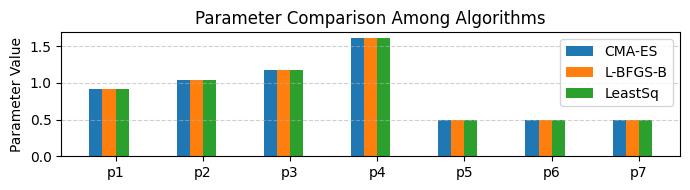

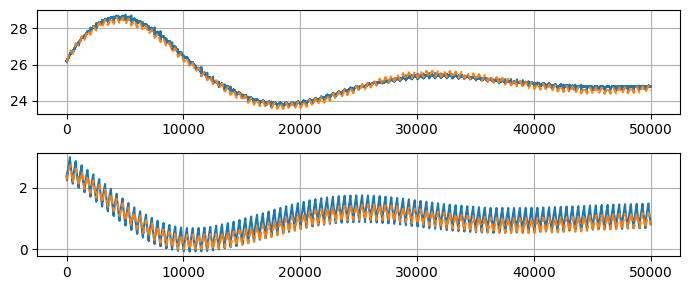

Parameter deviation (%)
CMA-ES  : [9.14, -4.22, -17.53, -60.58, 50.0, 50.0, 50.0]
L-BFGS-B: [9.14, -4.22, -17.53, -60.58, 50.0, 50.0, 50.0]
LeastSq : [9.14, -4.22, -17.53, -60.58, 50.0, 50.0, 50.0]


In [ ]:
# R6
# address1      = "C:/Users/BP15BQ/OneDrive - Aalborg Universitet/workfile/11_PINN/Experiment/CAUKiel20241006/20241218_Buck_3kpVoltLoop_48Vin24Vo_24Vin12Vo_9_6_3_new_osc_ziqiL_2/"
address2      = "Tek0223ALL.csv"       # Down, 10 MHz
time_slice1   = -0.0003

time_slice2   = time_slice1 + time_slice_length  
# Load data ------------ # 
if 1==1:
    loss_history = []

    # Load data
    d1            = datareader(address1+address2, 21, ["t", "i", "v", "s", "vin"],0,0) # Load the data
    d2            = dataslicer(d1, time_slice1, time_slice2,0) # Slice the signal

    df = d2
    target_waveform = np.array(df['v'])
    target_waveform_current =  np.array(df['i'])
    S1 = np.array(df['s'])

    xiv0 = np.array([target_waveform_current[0], target_waveform[0]])
    x0 = np.array([target_waveform_current[0], target_waveform[0]])

    target_waveform = target_waveform - target_waveform[0]
    target_waveform_current = target_waveform_current - target_waveform_current[0]
    # dutytemp = np.array(df['d']) 
    dutytemp = S1 # Fake duty cycle

Rloadreal = 23.12
@njit
def buck_convRK4_withDuty2(Lratio, Cratio, Rloadratio, RCratio, Rdsonratio, Rlratio, Vfratio,
                                Kp, Ki, t, yt, loadD1, dutytemp, xiv0, S1):
    L  = 1.36e-3 * Lratio
    C  = 140e-6 * Cratio
    Rc = 0.45 * RCratio
    Rl = 0.16 * Rlratio
    Ron = 0.04 * Rdsonratio
    Vd  = 0.9 * Vfratio

    Uin = 48.0
    Uref = 24.0
    R = Rloadreal * Rloadratio

    dt = t[1] - t[0]
    N = len(t)

    Il = xiv0[0]
    Uo = xiv0[1]
    Uc = xiv0[1]

    Ve, Vc, Vcc, Ve1, Vc1 = 0.0, 0.54, 0.0, 0.0, 0.5

    Ill = np.zeros(N)
    Uoo = np.zeros(N)
    DutyCycle = np.zeros(N)
    
    # if si == 1:  
    A11on = -(Ron + Rl)/(L)
    A12on = -1/L
    A21on = (R*L+C*R*Rc*(Ron+Rl))/((R+Rc)*L*C)
    A22on = -(C*R*Rc+L)/((R+Rc)*L*C)
    B1on = Uin/L
    B2on = Rc*R*Uin/(L*(R+Rc))

    A11off = -(Rl)/(L)
    A12off = -1/L
    A21off = (R*L+C*R*Rc*(Rl))/((R+Rc)*L*C)
    A22off = -(C*R*Rc+L)/((R+Rc)*L*C)

    B1off = -Vd/L
    B2off = -Rc*R*Vd/(L*(R+Rc))


    # ---------- Simulation ----------
    for i in range(N):
        # Vref
        if yt[i] > 0.99:
            Vc1, Ve1 = Vc, Ve
            Ve = Uref - Uo
            Vc = Vc1 + Kp * (Ve - Ve1) + Ki * (1 / 2e4) * Ve
            Vc = max(0.1, min(0.9, Vc))
            Vc = dutytemp[i]
            Vcc = Vc
            DutyCycle[i] = Vcc

        si = 1 if Vcc >= yt[i] else 0  # Switching state
        si = S1[i]

        #--------- State space ---------
        if si == 1:  
            A11 = A11on
            A12 = A12on
            A21 = A21on
            A22 = A22on
            B1 = B1on
            B2 = B2on
        else:       
            A11 = A11off
            A12 = A12off
            A21 = A21off
            A22 = A22off
            B1 = B1off
            B2 = B2off

        # ---------- RK4 ----------
        def f(Il, Uc):
            dx1 = A11 * Il + A12 * Uc + B1
            dx2 = A21 * Il + A22 * Uc + B2
            return dx1, dx2

        k1_Il, k1_Uc = f(Il, Uc)
        k2_Il, k2_Uc = f(Il + 0.5*dt*k1_Il, Uc + 0.5*dt*k1_Uc)
        k3_Il, k3_Uc = f(Il + 0.5*dt*k2_Il, Uc + 0.5*dt*k2_Uc)
        k4_Il, k4_Uc = f(Il + dt*k3_Il, Uc + dt*k3_Uc)

        Il += dt/6 * (k1_Il + 2*k2_Il + 2*k3_Il + k4_Il)
        Uc += dt/6 * (k1_Uc + 2*k2_Uc + 2*k3_Uc + k4_Uc)

        if Il < 0:
            Il = 0.0
        # Uo = (R/(R+Rc) * Il - Uc/(R+Rc)) * Rc + Uc
        Uo = Uc
        if i==0:
            Ill[i] = xiv0[0]
            Uoo[i] = xiv0[1]
            Uc = xiv0[1]

        Ill[i] = Il
        Uoo[i] = Uo

    return Ill, Uoo, DutyCycle

if 1== 1:
    results = compare_algorithms(target_waveform, target_waveform_current, dutytemp, S1)
    params = results['CMA-ES'][0]
    res = buck_convRK4_withDuty2(*params,0.04,10,t,yt,loadD1,dutytemp,xiv0,S1)

    fig,ax=plt.subplots(2,1,figsize=(7,3))
    ax[0].plot(target_waveform+xiv0[1]); ax[0].plot(res[1],'--')
    ax[1].plot(target_waveform_current+xiv0[0]); ax[1].plot(res[0],'--')
    for a in ax:a.grid(True)
    plt.tight_layout(); plt.show()


    # === Print estimation errors ===
    diff_pct = {name: (1 - val[0]) * 100 for name, val in results.items()}
    print("Parameter deviation (%)")
    for name, vals in diff_pct.items():
        print(f"{name:8s}:", np.round(vals,2).tolist())


results6 = results